#### SHAP - GPU -version

This most likely requires your computer/laptop has an Nvidia GPU with CUDA -support. 

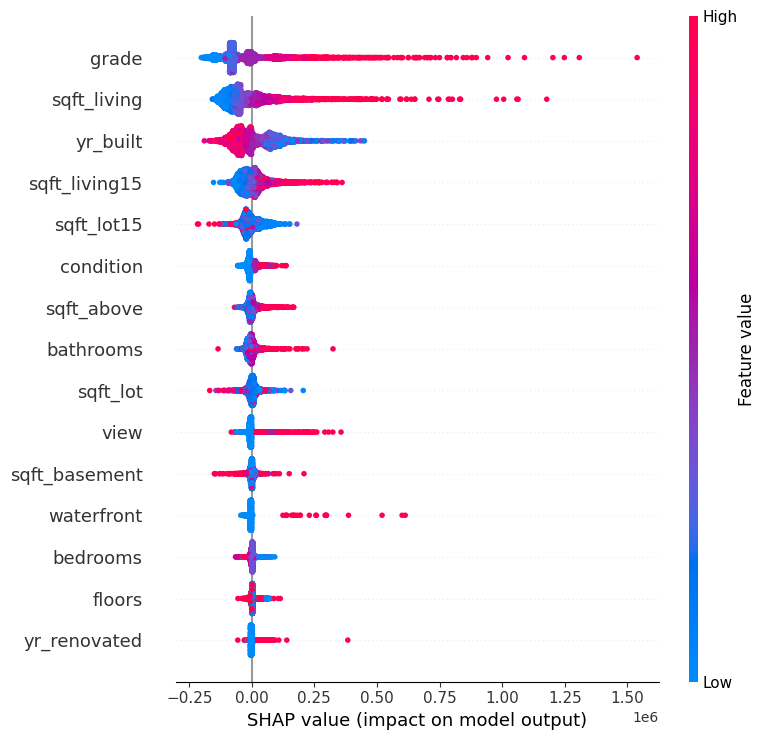

Feature Importances using SHAP:
          Feature    Importance
0        bedrooms   4809.016602
1       bathrooms  13605.241211
2     sqft_living  84115.632812
3        sqft_lot  13388.639648
4          floors   4352.423828
5      waterfront   5110.652344
6            view  10207.815430
7       condition  15329.843750
8           grade  95304.617188
9      sqft_above  13814.291016
10  sqft_basement   7411.572754
11       yr_built  63710.203125
12   yr_renovated   2819.506348
13  sqft_living15  38934.488281
14     sqft_lot15  28573.761719


In [1]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# load data
df = pd.read_csv("../houses.csv")

# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['id', 'date', 'zipcode', 'lat', 'long'], axis=1)

# Define features and target
X = df[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'sqft_living15',
       'sqft_lot15']]

y = df['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# use GPU-enabled XGBoost Regressor
model = xgb.XGBRegressor(tree_method='gpu_hist')
model.fit(X_train, y_train)

# Initialize SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test)

# Feature importance using SHAP values
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.mean(np.abs(shap_values.values), axis=0)  # shap_values.values for the matrix
})

print("Feature Importances using SHAP:")
print(importance)


In [2]:
# TODO add some regression metrics in order to evaluate if the model is even good or not
# SHAP values not that useful if the model is not very good, although it gives us the idea
# that the dataset needs to be improved still

___

### More experimental additional SHAP visualizations

Combination of AI, documentation and Googling

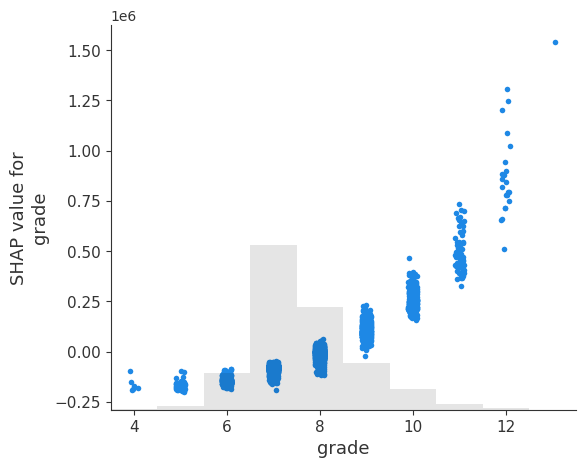

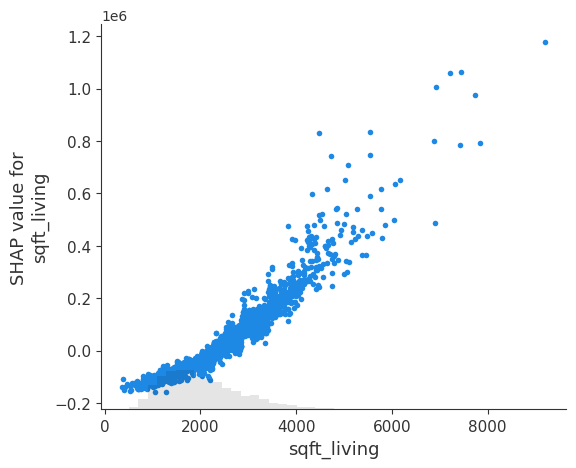

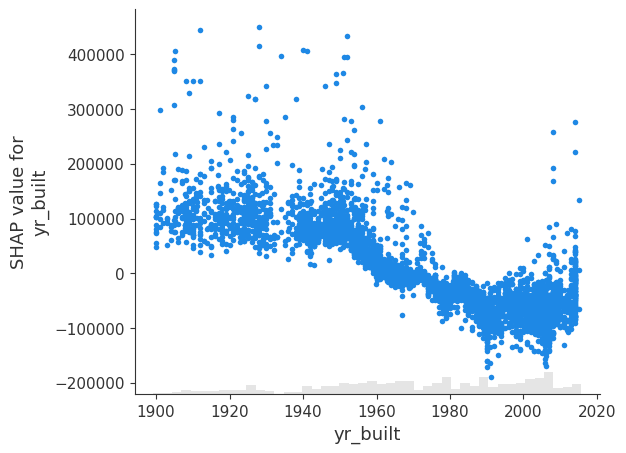

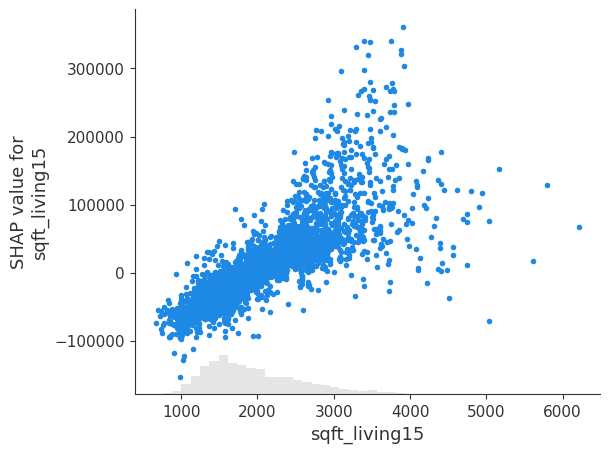

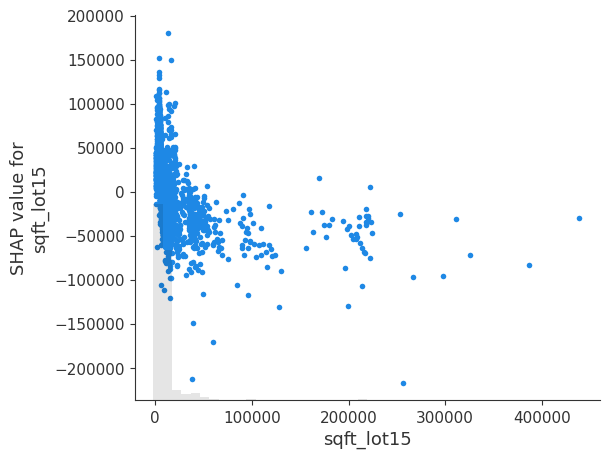

In [3]:
# Top 5 features from SHAP importance
top_features = importance.sort_values(by="Importance", ascending=False).Feature.values[:5]

for feature in top_features:
    shap.plots.scatter(shap_values[:, feature])


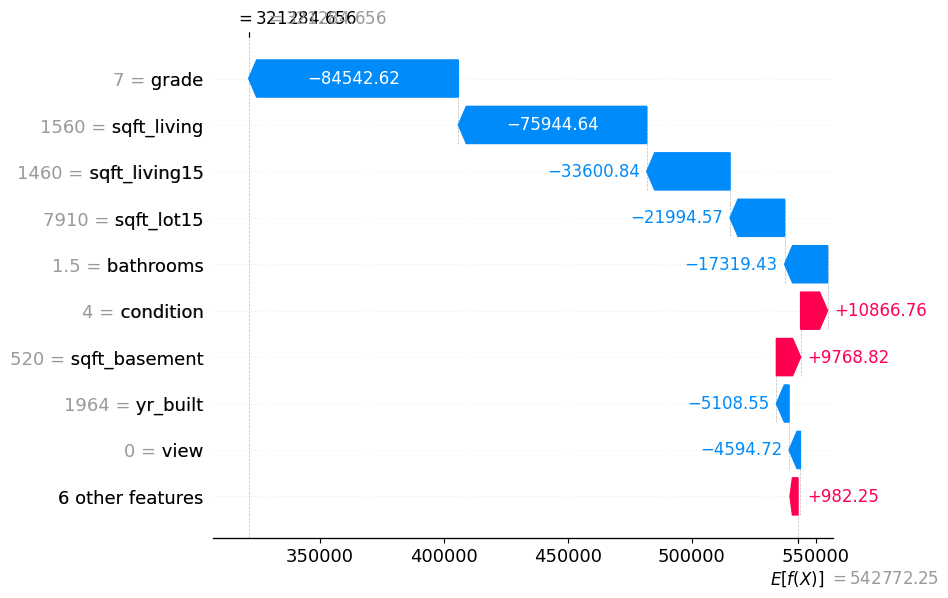

In [4]:
shap.plots.waterfall(shap_values[583])

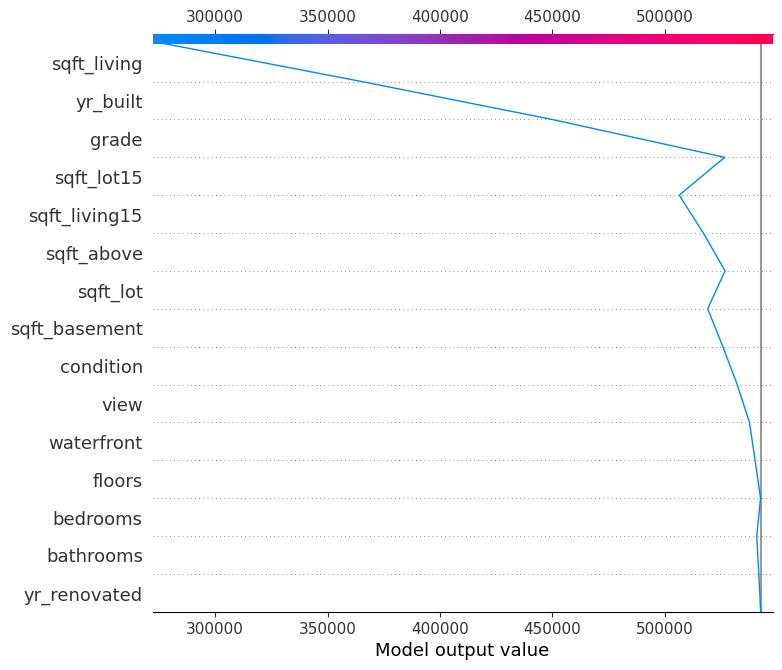

In [5]:
index = 367

shap.plots.decision(
    base_value=shap_values.base_values[index],
    shap_values=shap_values.values[index],
    feature_names=list(X_test.columns),
)


In [6]:
shap.initjs()

# For example, create a force plot for the first test instance:
shap.plots.force(
    base_value=shap_values.base_values[0],
    shap_values=shap_values.values[0],
    features=X_test.iloc[0],
    feature_names=list(X_test.columns)
)

### Feature interactions, seems useful on determining which variables are connected (outside the target)

**This plot looks promising, but might have bugs, not thoroughly tested**

Also careful when using these, pay attention to the variables you compare to each other.

In [7]:
# # Choose two features by their column names or indices
# feature_1 = 'sqft_living'
# feature_2 = 'grade'

# shap_interaction_values = explainer.shap_interaction_values(X_test)

# import matplotlib.pyplot as plt

# i = X_test.columns.get_loc(feature_1)
# j = X_test.columns.get_loc(feature_2)

# interaction_vals = shap_interaction_values[:, i, j]
# feat1_vals = X_test[feature_1]
# feat2_vals = X_test[feature_2]

# plt.scatter(feat1_vals, interaction_vals, c=feat2_vals, cmap='coolwarm')
# plt.xlabel(feature_1)
# plt.ylabel(f'SHAP Interaction with {feature_2}')
# plt.colorbar(label=feature_2)
# plt.title(f'Interaction SHAP values between {feature_1} and {feature_2}')
# plt.show()


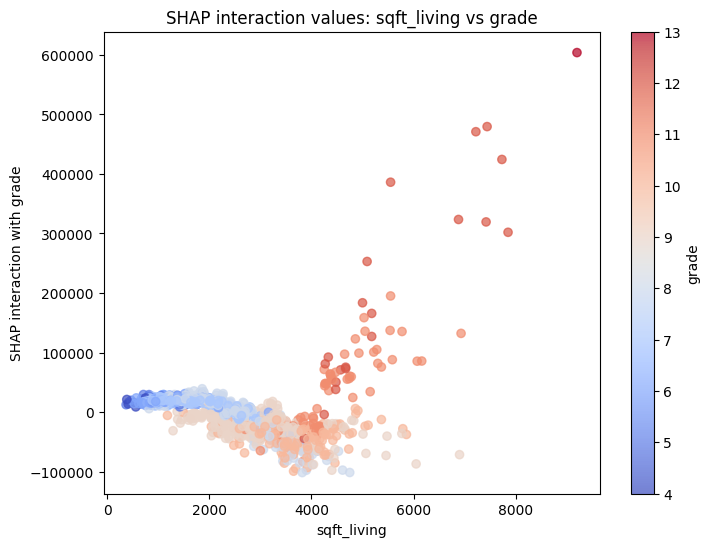

In [8]:
# a more simple version of the code above...
# needs still more testing if this actually works. 
# probably would be easiest to have a much more simple dataset
# and to test how it behaves here
import matplotlib.pyplot as plt

feature_1 = 'sqft_living'
feature_2 = 'grade'

shap_interaction_values = explainer.shap_interaction_values(X_test)

# Indices of the two features
i = X_test.columns.get_loc(feature_1)
j = X_test.columns.get_loc(feature_2)

# Extract values
interaction_vals = shap_interaction_values[:, i, j]
feat1_vals = X_test.iloc[:, i]
feat2_vals = X_test.iloc[:, j]

# Plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(feat1_vals, interaction_vals, c=feat2_vals, cmap='coolwarm', alpha=0.7)
plt.xlabel(feature_1)
plt.ylabel('SHAP interaction with ' + feature_2)
plt.colorbar(sc, label=feature_2)
plt.title(f'SHAP interaction values: {feature_1} vs {feature_2}')
plt.show()


In [9]:
# import matplotlib.pyplot as plt

# # Feature indices
# i = X_test.columns.get_loc(feature_1)
# j = X_test.columns.get_loc(feature_2)

# # Extract SHAP interaction values
# interaction_vals = shap_interaction_values[:, i, j]

# # Extract main effect SHAP values for feature_1 (diagonal)
# main_effect_vals = shap_interaction_values[:, i, i]

# # Total SHAP value for feature_1 including interaction with feature_2
# shap_vals_feature_1 = main_effect_vals + interaction_vals

# # Feature values
# feat1_vals = X_test[feature_1]
# feat2_vals = X_test[feature_2]

# # Plot dependence plot
# plt.figure(figsize=(8,6))
# scatter = plt.scatter(
#     feat1_vals,
#     shap_vals_feature_1,
#     c=feat2_vals,
#     cmap='coolwarm',
#     alpha=0.7
# )

# plt.xlabel(feature_1)
# plt.ylabel(f'SHAP value of {feature_1} (incl. interaction with {feature_2})')
# plt.colorbar(scatter, label=feature_2)
# plt.title(f'Dependence plot: SHAP value of {feature_1} colored by {feature_2}')
# plt.show()


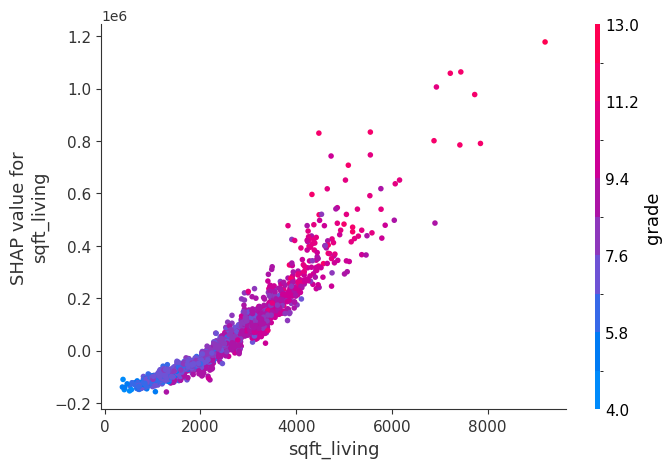

In [10]:
# a more simple version of the code above

# Example with TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Then plot
shap.dependence_plot(
    feature_1,            # can be index or name
    shap_values,          # 2D array [n_samples, n_features]
    X_test,               # DataFrame or array with feature names
    interaction_index=feature_2  # optional
)


In [16]:
from sklearn import metrics

predictions = model.predict(X_test)

# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, predictions), 2), "$")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, predictions), 2))

# mean house price is 540k$, range is between 75 000 to 7.7 million USD

MAE
114983.63 $

RMSE:
175047.65 $

R-squared:
0.74


In [15]:
df.describe()['price'].astype(int)

# mean house price is 540k$, range is between 75 000 to 7.7 million USD

count      21613
mean      540088
std       367127
min        75000
25%       321950
50%       450000
75%       645000
max      7700000
Name: price, dtype: int64